# ECG paper-to-digital deterministic pipeline (Google Colab)

This notebook implements the three-stage pipeline described in your proposal:

1. **Geometric rectification** using contour detection + homography.
2. **Image processing and signal extraction** using HSV/grid suppression, adaptive thresholding, and morphology.
3. **Signal digitization and calibration** using automatic 1 mV calibration-pulse detection, conversion to time/voltage, CSV/JSON export, and optional validation against PhysioNet/Kaggle reference signals.

The notebook is written for the **PhysioNet - Digitization of ECG Images** competition data and is configured to digitize the **long rhythm strip (Lead II)** by default.


In [1]:
import subprocess, sys
subprocess.check_call([
    sys.executable,
    "-m",
    "pip",
    "install",
    "-q",
    "kaggle",
    "opencv-python-headless",
    "scipy",
    "matplotlib",
    "pandas",
    "numpy",
])


0

In [2]:
import os
import sys
import json
import shutil
import zipfile
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from kaggle.api.kaggle_api_extended import KaggleApi
from scipy.signal import find_peaks
from scipy.ndimage import gaussian_filter1d
from IPython.display import display

# -----------------------------
# User configuration
# -----------------------------
COMPETITION = "physionet-ecg-image-digitization"
VARIANT = "0001"                # clean synthetic / clean color ECG image
SAMPLE_INDEX = 0                # row index inside train.csv
TARGET_LEAD = "II"              # long rhythm strip lead for validation
TARGET_FS = 500                 # proposal target sampling frequency
FORCE_REDOWNLOAD = False
AUTO_TUNE_ON_REFERENCE = True  # search a few deterministic candidate settings on labeled train samples

# Optional manual overrides (set to None unless needed)
MANUAL_PAGE_QUAD = None         # e.g. np.array([[x1,y1],[x2,y2],[x3,y3],[x4,y4]], dtype=np.float32)
MANUAL_STRIP_BBOX = None        # e.g. (x1, y1, x2, y2) in rectified image coordinates

# ECG paper standards from the proposal / clinical convention
STANDARD_MM_PER_SEC = 25.0      # 25 mm/s
STANDARD_MM_PER_MV = 10.0       # 10 mm per mV
CAL_PULSE_DURATION_SEC = 0.2    # typical calibration pulse width
CAL_PULSE_HEIGHT_MV = 1.0       # calibration pulse amplitude

if "google.colab" in sys.modules:
    BASE_DIR = Path("/content/ecg_digitization_project")
else:
    BASE_DIR = Path.cwd() / "ecg_digitization_project"

DOWNLOAD_DIR = BASE_DIR / "downloads"
OUTPUT_DIR = BASE_DIR / "outputs"
DOWNLOAD_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("BASE_DIR   :", BASE_DIR)
print("DOWNLOAD_DIR:", DOWNLOAD_DIR)
print("OUTPUT_DIR  :", OUTPUT_DIR)


BASE_DIR   : /content/ecg_digitization_project
DOWNLOAD_DIR: /content/ecg_digitization_project/downloads
OUTPUT_DIR  : /content/ecg_digitization_project/outputs


In [3]:
def setup_kaggle_auth():
    """
    Looks for Kaggle credentials in:
      1) ~/.kaggle/kaggle.json
      2) ./kaggle.json or /content/kaggle.json
      3) KAGGLE_USERNAME + KAGGLE_KEY env vars
      4) Colab file upload prompt
    """
    kaggle_dir = Path.home() / ".kaggle"
    kaggle_dir.mkdir(parents=True, exist_ok=True)
    kaggle_json = kaggle_dir / "kaggle.json"

    if kaggle_json.exists():
        os.chmod(kaggle_json, 0o600)
        return

    for candidate in [Path.cwd() / "kaggle.json", Path("/content/kaggle.json")]:
        if candidate.exists():
            shutil.copy(candidate, kaggle_json)
            os.chmod(kaggle_json, 0o600)
            return

    if os.environ.get("KAGGLE_USERNAME") and os.environ.get("KAGGLE_KEY"):
        return

    if "google.colab" in sys.modules:
        from google.colab import files
        print("Upload your kaggle.json file...")
        uploaded = files.upload()
        if "kaggle.json" not in uploaded:
            raise FileNotFoundError("kaggle.json was not uploaded.")
        with open(kaggle_json, "wb") as f:
            f.write(uploaded["kaggle.json"])
        os.chmod(kaggle_json, 0o600)
        return

    raise RuntimeError(
        "Kaggle credentials not found. Put kaggle.json in ~/.kaggle/, "
        "or set KAGGLE_USERNAME and KAGGLE_KEY."
    )

def _extract_if_needed(local_path: Path) -> Path:
    """
    Kaggle sometimes downloads the exact file, sometimes a .zip wrapper.
    This function returns the extracted path in both cases.
    """
    if local_path.exists():
        return local_path

    zip_candidate = local_path.with_name(local_path.name + ".zip")
    if zip_candidate.exists():
        with zipfile.ZipFile(zip_candidate, "r") as zf:
            zf.extractall(local_path.parent)
        if local_path.exists():
            return local_path

    matches = list(local_path.parent.glob(local_path.name))
    if matches:
        return matches[0]

    raise FileNotFoundError(f"Could not find downloaded file for {local_path.name}")

def download_competition_file(api: KaggleApi, remote_file: str, out_dir: Path, force: bool = False) -> Path:
    out_dir.mkdir(parents=True, exist_ok=True)
    local_name = Path(remote_file).name
    local_path = out_dir / local_name

    if local_path.exists() and not force:
        return local_path

    api.competition_download_file(
        COMPETITION,
        remote_file,
        path=str(out_dir),
        force=force,
        quiet=False,
    )
    return _extract_if_needed(local_path)

setup_kaggle_auth()

def create_authenticated_kaggle_api():
    from kaggle.api.kaggle_api_extended import KaggleApi
    try:
        api = KaggleApi()
        api.authenticate()
        return api
    except NameError as e:
        raise RuntimeError(
            "Kaggle authentication failed. Upload kaggle.json first, then rerun this cell.\n"
            "In Colab, upload kaggle.json when prompted or place it at /root/.kaggle/kaggle.json with chmod 600.\n"
            f"Original error: {e}"
        ) from e
    except OSError as e:
        raise RuntimeError(
            "Kaggle authentication failed. Make sure kaggle.json is present and valid.\n"
            "Expected path: /root/.kaggle/kaggle.json (or ~/.kaggle/kaggle.json).\n"
            f"Original error: {e}"
        ) from e

api = create_authenticated_kaggle_api()

def get_train_meta(force=False):
    """Load train.csv metadata on demand so later cells do not depend on execution order."""
    train_csv_path = download_competition_file(api, "train.csv", DOWNLOAD_DIR, force=force)
    train_meta_df = pd.read_csv(train_csv_path)
    return train_meta_df

train_meta = get_train_meta(force=FORCE_REDOWNLOAD)

print("train.csv loaded.")
display(train_meta.head())


100%|██████████| 19.5k/19.5k [00:00<00:00, 10.2MB/s]


train.csv loaded.


,id,fs,sig_len
0,7663343,500,5000
1,10140238,1000,10000
2,11842146,1000,10000
3,19030958,250,2500
4,19585145,512,5120


In [4]:
def load_sample_from_train(sample_index=0, variant="0001", target_lead="II", force=False, train_meta_df=None):
    if train_meta_df is None:
        train_meta_df = get_train_meta(force=force)

    row = train_meta_df.iloc[int(sample_index)]
    sample_id = str(row["id"])
    fs = int(row["fs"])
    sig_len = int(row["sig_len"])

    image_remote = f"train/{sample_id}/{sample_id}-{variant}.png"
    signal_remote = f"train/{sample_id}/{sample_id}.csv"

    image_path = download_competition_file(api, image_remote, DOWNLOAD_DIR, force=force)
    signal_path = download_competition_file(api, signal_remote, DOWNLOAD_DIR, force=force)

    return {
        "sample_id": sample_id,
        "fs": fs,
        "sig_len": sig_len,
        "target_lead": target_lead,
        "image_path": image_path,
        "signal_path": signal_path,
    }

sample_info = load_sample_from_train(
    sample_index=SAMPLE_INDEX,
    variant=VARIANT,
    target_lead=TARGET_LEAD,
    force=FORCE_REDOWNLOAD
)

print(json.dumps({k: str(v) for k, v in sample_info.items()}, indent=2))


100%|██████████| 367k/367k [00:00<00:00, 7.59MB/s]

100%|██████████| 156k/156k [00:00<00:00, 6.03MB/s]


{
  "sample_id": "7663343",
  "fs": "500",
  "sig_len": "5000",
  "target_lead": "II",
  "image_path": "/content/ecg_digitization_project/downloads/7663343-0001.png",
  "signal_path": "/content/ecg_digitization_project/downloads/7663343.csv"
}


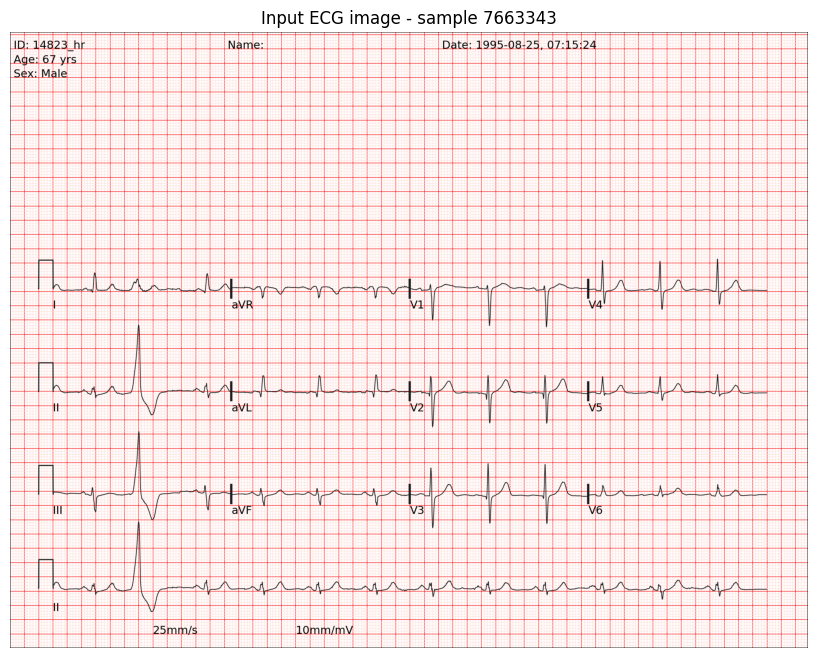

In [5]:
def read_rgb_image(path):
    bgr = cv2.imread(str(path), cv2.IMREAD_COLOR)
    if bgr is None:
        raise FileNotFoundError(f"Could not read image: {path}")
    return cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)

def show_image(img, title="", figsize=(12, 8), cmap=None):
    plt.figure(figsize=figsize)
    if cmap is None:
        plt.imshow(img)
    else:
        plt.imshow(img, cmap=cmap)
    plt.title(title)
    plt.axis("off")
    plt.show()

rgb_preview = read_rgb_image(sample_info["image_path"])
show_image(rgb_preview, f"Input ECG image - sample {sample_info['sample_id']}")


In [6]:
# ==========================================================
# Stage 1 - Geometric rectification (paper boundary + warp)
# ==========================================================

def order_points(pts):
    pts = np.asarray(pts, dtype=np.float32)
    rect = np.zeros((4, 2), dtype=np.float32)

    s = pts.sum(axis=1)
    rect[0] = pts[np.argmin(s)]   # top-left
    rect[2] = pts[np.argmax(s)]   # bottom-right

    d = np.diff(pts, axis=1).reshape(-1)
    rect[1] = pts[np.argmin(d)]   # top-right
    rect[3] = pts[np.argmax(d)]   # bottom-left
    return rect

def four_point_transform(image, pts):
    rect = order_points(pts)
    (tl, tr, br, bl) = rect

    width_a = np.linalg.norm(br - bl)
    width_b = np.linalg.norm(tr - tl)
    max_width = int(max(width_a, width_b))

    height_a = np.linalg.norm(tr - br)
    height_b = np.linalg.norm(tl - bl)
    max_height = int(max(height_a, height_b))

    dst = np.array(
        [
            [0, 0],
            [max_width - 1, 0],
            [max_width - 1, max_height - 1],
            [0, max_height - 1],
        ],
        dtype=np.float32,
    )

    M = cv2.getPerspectiveTransform(rect, dst)
    warped = cv2.warpPerspective(image, M, (max_width, max_height))
    return warped, rect, M

def detect_paper_quad(rgb):
    """
    Detect the ECG paper boundary. If no reliable quadrilateral is found,
    return None and keep the image unchanged.
    """
    gray = cv2.cvtColor(rgb, cv2.COLOR_RGB2GRAY)
    blur = cv2.GaussianBlur(gray, (5, 5), 0)

    edges = cv2.Canny(blur, 50, 150)
    edges = cv2.dilate(edges, np.ones((3, 3), np.uint8), iterations=1)
    edges = cv2.morphologyEx(edges, cv2.MORPH_CLOSE, np.ones((7, 7), np.uint8), iterations=2)

    contours, _ = cv2.findContours(edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    contours = sorted(contours, key=cv2.contourArea, reverse=True)

    h, w = gray.shape
    img_area = h * w

    for cnt in contours[:20]:
        area = cv2.contourArea(cnt)
        if area < 0.25 * img_area:
            continue

        peri = cv2.arcLength(cnt, True)
        approx = cv2.approxPolyDP(cnt, 0.02 * peri, True)

        if len(approx) == 4:
            quad = approx.reshape(4, 2).astype(np.float32)
            return quad, {"method": "approxPolyDP", "area_ratio": float(area / img_area), "edges": edges}

        rect = cv2.minAreaRect(cnt)
        box = cv2.boxPoints(rect).astype(np.float32)
        box_area = cv2.contourArea(box)
        if box_area >= 0.25 * img_area:
            return box, {"method": "minAreaRect", "area_ratio": float(box_area / img_area), "edges": edges}

    return None, {"method": "identity", "area_ratio": 0.0, "edges": edges}

def rectify_page(rgb, manual_quad=None):
    if manual_quad is not None:
        warped, quad, M = four_point_transform(rgb, np.asarray(manual_quad, dtype=np.float32))
        return warped, {"quad": quad, "transform": M, "used_rectification": True, "method": "manual"}

    quad, meta = detect_paper_quad(rgb)
    if quad is None:
        return rgb.copy(), {"quad": None, "transform": None, "used_rectification": False, **meta}

    warped, quad, M = four_point_transform(rgb, quad)
    return warped, {"quad": quad, "transform": M, "used_rectification": True, **meta}


In [7]:
# ==========================================================
# Stage 2 - HSV/grid suppression + adaptive thresholding
# ==========================================================

def estimate_period_from_projection(proj, lag_min=4, lag_max=180):
    """
    Estimate the ECG small-box spacing (1 mm) from a 1D projection.

    The strongest autocorrelation peak is often the major-grid spacing (5 mm),
    not the small-box spacing. This function scores multiple candidate peaks and
    prefers the smallest lag that is strongly supported by its harmonics.
    """
    proj = np.asarray(proj, dtype=np.float32)
    proj = proj - proj.mean()
    proj = proj / (proj.std() + 1e-8)

    ac = np.correlate(proj, proj, mode="full")[len(proj) - 1 :]
    lag_max = min(lag_max, len(ac) - 1)
    if lag_max <= lag_min + 2:
        return 8

    search = ac[lag_min : lag_max + 1]
    peaks, _ = find_peaks(search, distance=2)
    if len(peaks) == 0:
        return int(np.argmax(search) + lag_min)

    peak_lags = peaks + lag_min
    peak_vals = search[peaks]

    candidates = []
    for lag, val in zip(peak_lags, peak_vals):
        support = float(val)

        # Reward candidates whose multiples are also present.
        for mult, weight in [(2, 0.9), (3, 0.7), (4, 0.6), (5, 1.1), (6, 0.4)]:
            target = mult * lag
            if target > lag_max:
                continue
            nearest_idx = int(np.argmin(np.abs(peak_lags - target)))
            nearest_lag = int(peak_lags[nearest_idx])
            if abs(nearest_lag - target) <= max(1, int(0.08 * lag)):
                support += float(weight * peak_vals[nearest_idx])

        # Slight preference for smaller plausible lags
        support += 0.05 * (lag_max - lag) / max(lag_max, 1)
        candidates.append((support, int(lag)))

    candidates.sort(reverse=True)
    best_lag = int(candidates[0][1])

    # If the dominant peak is probably the major grid (5 mm), try its subharmonic.
    for div in [5, 2]:
        candidate = best_lag / div
        if candidate < lag_min:
            continue
        candidate = int(round(candidate))
        if candidate < lag_min or candidate > lag_max:
            continue
        local_strength = ac[candidate]
        best_strength = ac[best_lag]
        if local_strength >= 0.18 * best_strength:
            best_lag = candidate
            break

    return int(best_lag)

def estimate_grid_spacing_px(rgb):
    """
    Estimate ECG small-box spacing (1 mm) in pixels.

    For clean PhysioNet `-0001` images, the red grid often produces a much
    stronger response at the 5 mm major-grid spacing than at the 1 mm spacing.
    This function therefore uses a red-emphasis image and a harmonic-aware
    autocorrelation estimator.
    """
    rgb = np.asarray(rgb, dtype=np.uint8)
    r = rgb[:, :, 0].astype(np.float32)
    g = rgb[:, :, 1].astype(np.float32)
    b = rgb[:, :, 2].astype(np.float32)

    # Red emphasis suppresses the grayscale ECG trace and boosts the paper grid.
    red_score = r - 0.5 * g - 0.5 * b
    red_score = cv2.GaussianBlur(red_score, (0, 0), 1.2)

    x_proj = red_score.mean(axis=0)
    y_proj = red_score.mean(axis=1)

    px_per_mm_x = estimate_period_from_projection(
        x_proj,
        lag_min=4,
        lag_max=min(120, max(24, rgb.shape[1] // 4)),
    )
    px_per_mm_y = estimate_period_from_projection(
        y_proj,
        lag_min=4,
        lag_max=min(120, max(24, rgb.shape[0] // 4)),
    )

    px_per_mm_x = int(np.clip(px_per_mm_x, 4, 40))
    px_per_mm_y = int(np.clip(px_per_mm_y, 4, 40))
    return px_per_mm_x, px_per_mm_y, x_proj, y_proj

def build_signal_mask(rgb):
    """
    Keep dark ECG trace while suppressing red grid lines.
    Works on both clean synthetic images and many photographed pages.
    """
    hsv = cv2.cvtColor(rgb, cv2.COLOR_RGB2HSV)
    gray = cv2.cvtColor(rgb, cv2.COLOR_RGB2GRAY)

    h = hsv[:, :, 0]
    s = hsv[:, :, 1]
    v = hsv[:, :, 2]

    # Red/pink grid suppression
    red_mask = (((h <= 15) | (h >= 165)) & (s >= 35) & (v >= 70)).astype(np.uint8) * 255

    gray_no_grid = gray.copy()
    gray_no_grid[red_mask > 0] = 255

    block_size = 31 if min(gray.shape) > 300 else 21
    adaptive = cv2.adaptiveThreshold(
        gray_no_grid,
        255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY_INV,
        block_size,
        9,
    )

    # Add a dark-pixel safety mask so thin black strokes are preserved
    dark_cut = min(int(np.percentile(gray, 35)) + 15, 170)
    dark_mask = (gray < dark_cut).astype(np.uint8) * 255

    mask = cv2.bitwise_or(adaptive, dark_mask)
    mask[red_mask > 0] = 0

    mask = cv2.medianBlur(mask, 3)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, np.ones((2, 2), np.uint8), iterations=1)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, np.ones((3, 3), np.uint8), iterations=1)
    return (mask > 0).astype(np.uint8)

def _group_consecutive(indices):
    if len(indices) == 0:
        return []
    groups = []
    start = indices[0]
    prev = indices[0]
    for idx in indices[1:]:
        if idx == prev + 1:
            prev = idx
        else:
            groups.append((start, prev))
            start = idx
            prev = idx
    groups.append((start, prev))
    return groups

def find_strip_bands(mask):
    """
    Detect horizontal ECG bands (rows with signal activity).
    """
    row_density = gaussian_filter1d(mask.mean(axis=1).astype(np.float32), sigma=6)
    thresh = row_density.mean() + 0.35 * row_density.std()
    active_rows = np.where(row_density > thresh)[0]

    groups = _group_consecutive(active_rows)
    h, w = mask.shape

    bands = []
    for y1, y2 in groups:
        if (y2 - y1 + 1) < max(25, int(0.03 * h)):
            continue
        pad = max(8, int(0.01 * h))
        yy1 = max(0, y1 - pad)
        yy2 = min(h - 1, y2 + pad)

        band = mask[yy1 : yy2 + 1, :]
        col_density = gaussian_filter1d(band.mean(axis=0).astype(np.float32), sigma=4)
        col_thresh = max(0.002, 0.35 * np.percentile(col_density, 90))
        active_cols = np.where(col_density > col_thresh)[0]
        if len(active_cols) == 0:
            x1, x2 = int(0.03 * w), int(0.98 * w)
        else:
            x1 = max(0, int(active_cols.min()) - 10)
            x2 = min(w - 1, int(active_cols.max()) + 10)

        bands.append((x1, yy1, x2, yy2))

    # Fallback: use lower part of image if detection is weak
    if len(bands) == 0:
        bands = [(int(0.03 * w), int(0.72 * h), int(0.98 * w), int(0.95 * h))]

    return bands, row_density

def choose_target_strip(rectified_rgb, signal_mask, target_lead="II", manual_bbox=None):
    if manual_bbox is not None:
        return tuple(map(int, manual_bbox)), {"selection_method": "manual"}

    bands, row_density = find_strip_bands(signal_mask)

    # For standard 12-lead layouts, the long rhythm strip is usually the lowest band.
    # We default to the last detected band for Lead II rhythm-strip extraction.
    if target_lead.upper() == "II" and len(bands) >= 2:
        bbox = max(bands, key=lambda b: b[3])  # band with lowest bottom edge
        method = "lowest_band_for_long_rhythm_strip"
    else:
        bbox = max(bands, key=lambda b: (b[2] - b[0]) * (b[3] - b[1]))
        method = "largest_detected_band"

    return bbox, {"selection_method": method, "all_bands": bands, "row_density": row_density}


In [8]:
# ==========================================================
# Stage 3 - calibration pulse + waveform digitization
# ==========================================================

def crop_from_bbox(img, bbox):
    x1, y1, x2, y2 = map(int, bbox)
    return img[y1 : y2 + 1, x1 : x2 + 1]

def translate_bbox_to_local(inner_bbox, outer_bbox):
    ix1, iy1, ix2, iy2 = map(int, inner_bbox)
    ox1, oy1, ox2, oy2 = map(int, outer_bbox)
    return (ix1 - ox1, iy1 - oy1, ix2 - ox1, iy2 - oy1)

def expand_strip_bbox_for_extraction(
    bbox,
    image_shape,
    px_per_mm,
    top_mm=10.0,
    bottom_mm=4.0,
    left_mm=1.0,
    right_mm=1.0,
):
    """
    Expand a thin Lead II strip into a modestly taller extraction crop.

    This is intentionally conservative:
    it should capture the tall early QRS without swallowing multiple lead rows.
    """
    if len(image_shape) == 3:
        h, w = image_shape[:2]
    else:
        h, w = image_shape

    x1, y1, x2, y2 = map(int, bbox)

    pad_top = int(round(top_mm * px_per_mm))
    pad_bottom = int(round(bottom_mm * px_per_mm))
    pad_left = int(round(left_mm * px_per_mm))
    pad_right = int(round(right_mm * px_per_mm))

    x1 = max(0, x1 - pad_left)
    x2 = min(w - 1, x2 + pad_right)
    y1 = max(0, y1 - pad_top)
    y2 = min(h - 1, y2 + pad_bottom)

    return (int(x1), int(y1), int(x2), int(y2))

def isolate_target_strip_from_expanded_mask(expanded_mask, base_bbox_local):
    """
    Keep only connected structures touching the selected Lead II row.
    """
    mask = (expanded_mask > 0).astype(np.uint8)

    work = cv2.morphologyEx(
        mask * 255,
        cv2.MORPH_CLOSE,
        cv2.getStructuringElement(cv2.MORPH_RECT, (5, 3)),
        iterations=1,
    )
    work = (work > 0).astype(np.uint8)

    bx1, by1, bx2, by2 = map(int, base_bbox_local)

    seed = np.zeros_like(work, dtype=np.uint8)
    seed[max(0, by1 - 2):min(work.shape[0], by2 + 3),
         max(0, bx1):min(work.shape[1], bx2 + 1)] = 1

    n_labels, labels, stats, _ = cv2.connectedComponentsWithStats(work, connectivity=8)
    keep = np.zeros_like(work, dtype=np.uint8)

    seed_labels = np.unique(labels[seed > 0])
    seed_labels = seed_labels[seed_labels > 0]

    for lab in seed_labels:
        keep[labels == lab] = 1

    if keep.sum() == 0:
        return work

    return keep

def detect_calibration_pulse(strip_mask):
    """
    Detect the 1 mV calibration pulse from the left side of the strip.

    Instead of using the whole connected component width/height, this function
    looks for the two tall vertical edges of the square wave and measures:
      - width_px  = distance between rise and fall edges
      - height_px = top plateau to baseline
    """
    h, w = strip_mask.shape
    search_w = max(40, int(0.18 * w))
    roi = (strip_mask[:, :search_w] > 0).astype(np.uint8)

    # Clean and connect the square-wave shape.
    roi = cv2.morphologyEx(
        roi * 255,
        cv2.MORPH_CLOSE,
        cv2.getStructuringElement(cv2.MORPH_RECT, (5, 3)),
        iterations=1,
    )
    roi = (roi > 0).astype(np.uint8)

    heights = np.zeros(search_w, dtype=np.float32)
    tops = np.full(search_w, np.nan, dtype=np.float32)
    bottoms = np.full(search_w, np.nan, dtype=np.float32)

    for x in range(search_w):
        rows = np.where(roi[:, x] > 0)[0]
        if rows.size == 0:
            continue
        tops[x] = float(rows[0])
        bottoms[x] = float(rows[-1])
        heights[x] = float(rows[-1] - rows[0] + 1)

    positive_heights = heights[heights > 0]
    if len(positive_heights) == 0:
        return None

    tall_cutoff = max(0.45 * h, np.percentile(positive_heights, 90))
    tall_cols = np.where(heights >= tall_cutoff)[0]
    if len(tall_cols) < 2:
        return None

    split_idx = np.where(np.diff(tall_cols) > 2)[0] + 1
    groups = np.split(tall_cols, split_idx)
    groups = [g for g in groups if len(g) >= 1]

    if len(groups) < 2:
        return None

    # Use the first two tall edge groups near the left margin.
    rise_group = groups[0]
    fall_group = groups[1]
    x_rise = int(np.round(rise_group.mean()))
    x_fall = int(np.round(fall_group.mean()))

    if x_fall <= x_rise + 2:
        return None

    plateau_x1 = min(search_w - 1, x_rise + 1)
    plateau_x2 = max(plateau_x1 + 1, min(search_w, x_fall))
    plateau = roi[:, plateau_x1:plateau_x2]

    plateau_rows = np.where(plateau > 0)[0]
    if plateau_rows.size == 0:
        return None

    top_y = int(np.round(np.percentile(plateau_rows, 10)))

    baseline_candidates = []
    for xs, xe in [
        (max(0, x_rise - 20), max(0, x_rise - 2)),
        (min(search_w, x_fall + 2), min(search_w, x_fall + 20)),
    ]:
        if xe > xs:
            local_bottoms = bottoms[xs:xe]
            local_bottoms = local_bottoms[np.isfinite(local_bottoms)]
            baseline_candidates.extend(local_bottoms.tolist())

    if len(baseline_candidates) == 0:
        finite_bottoms = bottoms[np.isfinite(bottoms)]
        if len(finite_bottoms) == 0:
            return None
        baseline_y = int(np.round(np.percentile(finite_bottoms, 90)))
    else:
        baseline_y = int(np.round(np.percentile(np.asarray(baseline_candidates), 80)))

    width_px = int(x_fall - x_rise)
    height_px = int(baseline_y - top_y)

    if width_px < 4 or height_px < max(8, int(0.15 * h)):
        return None

    bbox = (
        int(max(0, x_rise - 2)),
        int(max(0, top_y)),
        int(min(search_w - 1, x_fall + 2)),
        int(min(h - 1, baseline_y)),
    )

    return {
        "bbox": bbox,
        "width_px": int(width_px),
        "height_px": int(height_px),
        "baseline_y": int(baseline_y),
        "x_rise": int(x_rise),
        "x_fall": int(x_fall),
    }


def detect_calibration_pulse_constrained(strip_mask, base_bbox_local, px_per_mm_est):
    """
    Detect the 1 mV pulse only in a local band around the selected Lead II row.
    This avoids confusing neighboring rows or tall multi-row structures with the pulse.
    """
    h, w = strip_mask.shape
    bx1, by1, bx2, by2 = map(int, base_bbox_local)

    search_w = max(40, int(0.15 * w))
    expected_h = max(8, int(round(10.0 * px_per_mm_est)))  # 1 mV = 10 mm
    expected_w = max(4, int(round(5.0 * px_per_mm_est)))   # 0.2 s at 25 mm/s = 5 mm

    ry1 = max(0, by1 - expected_h - 8)
    ry2 = min(h - 1, by2 + int(0.5 * expected_h) + 8)

    roi = strip_mask[ry1:ry2 + 1, :search_w]
    info = detect_calibration_pulse(roi)
    if info is None:
        return None

    height_ratio = info["height_px"] / max(expected_h, 1e-6)
    width_ratio = info["width_px"] / max(expected_w, 1e-6)

    if not (0.45 <= height_ratio <= 1.7 and 0.45 <= width_ratio <= 1.8):
        return None

    x1, y1, x2, y2 = info["bbox"]
    info = dict(info)
    info["bbox"] = (int(x1), int(y1 + ry1), int(x2), int(y2 + ry1))
    info["baseline_y"] = int(info["baseline_y"] + ry1)
    return info

def build_waveform_component_mask(strip_rgb, strip_mask, calibration_info=None):
    """
    Keep connected components likely to belong to the waveform.
    Optionally remove the calibration-pulse area after using it for scaling.
    """
    mask = strip_mask.copy().astype(np.uint8)

    if calibration_info is not None:
        x1, y1, x2, y2 = calibration_info["bbox"]
        pad_x = 4
        pad_y = 4
        mask[max(0, y1 - pad_y):min(mask.shape[0], y2 + pad_y + 1),
             max(0, x1 - pad_x):min(mask.shape[1], x2 + pad_x + 1)] = 0

    mask = cv2.morphologyEx(
        mask * 255,
        cv2.MORPH_CLOSE,
        cv2.getStructuringElement(cv2.MORPH_RECT, (5, 3)),
        iterations=1,
    )
    mask = (mask > 0).astype(np.uint8)

    n_labels, labels, stats, _ = cv2.connectedComponentsWithStats(mask, connectivity=8)
    if n_labels <= 1:
        return mask

    h, w = mask.shape
    keep = np.zeros_like(mask, dtype=np.uint8)

    for i in range(1, n_labels):
        x, y, bw, bh, area = stats[i]
        if bw > 0.06 * w or area > 0.0008 * h * w:
            keep[labels == i] = 1

    if keep.sum() == 0:
        keep = mask

    return keep

def track_centerline(mask, intensity_image=None):
    """
    Column-wise waveform tracking with continuity preference.

    Key fix:
    - Do NOT use the mean row of a thick vertical segment, because that shrinks
      sharp ECG peaks.
    - Instead, within the chosen connected segment, pick the darkest pixel row
      from the original strip image, with a continuity preference to the
      previous column.
    """
    h, w = mask.shape
    y_trace = np.full(w, np.nan, dtype=np.float32)
    col_heights = np.zeros(w, dtype=np.float32)

    gray = None
    if intensity_image is not None:
        if intensity_image.ndim == 3:
            gray = cv2.cvtColor(intensity_image, cv2.COLOR_RGB2GRAY).astype(np.float32)
        else:
            gray = intensity_image.astype(np.float32)

    prev_y = None
    for x in range(w):
        rows = np.where(mask[:, x] > 0)[0]
        if rows.size == 0:
            continue

        col_heights[x] = float(rows[-1] - rows[0] + 1)

        split_idx = np.where(np.diff(rows) > 1)[0] + 1
        segments = np.split(rows, split_idx)
        segments = [seg for seg in segments if len(seg) > 0]
        if len(segments) == 0:
            continue

        if prev_y is None or np.isnan(prev_y):
            centers = np.array([seg.mean() for seg in segments], dtype=np.float32)
            seg = segments[int(np.argmin(np.abs(centers - np.median(centers))))]
        else:
            centers = np.array([seg.mean() for seg in segments], dtype=np.float32)
            seg = segments[int(np.argmin(np.abs(centers - prev_y)))]

        if gray is None:
            # Fallback if original intensity image is unavailable
            chosen_y = float(seg.mean())
        else:
            vals = gray[seg, x]
            min_val = float(vals.min())
            dark_rows = seg[vals <= (min_val + 4.0)]  # near-darkest pixels only

            if prev_y is None or np.isnan(prev_y):
                chosen_y = float(np.median(dark_rows))
            else:
                chosen_y = float(dark_rows[np.argmin(np.abs(dark_rows - prev_y))])

        y_trace[x] = chosen_y
        prev_y = chosen_y

    valid = np.where(~np.isnan(y_trace))[0]
    if len(valid) < 10:
        raise RuntimeError("Too few valid waveform columns found.")

    y_trace[: valid[0]] = y_trace[valid[0]]
    y_trace[valid[-1] + 1 :] = y_trace[valid[-1]]
    y_trace = np.interp(np.arange(w), valid, y_trace[valid]).astype(np.float32)
    return y_trace, col_heights

def find_usable_x_range(waveform_mask, col_heights, calibration_info=None):
    active_cols = np.where(waveform_mask.sum(axis=0) > 0)[0]
    if len(active_cols) == 0:
        return 0, waveform_mask.shape[1] - 1

    start_col = int(active_cols[0])
    end_col = int(active_cols[-1])

    if calibration_info is not None:
        # Leave a larger guard band after the pulse to avoid contaminating
        # the digitized trace with the calibration square wave.
        start_col = max(start_col, int(calibration_info["bbox"][2] + 10))

    positive_heights = col_heights[col_heights > 0]
    if len(positive_heights) > 0:
        tall_cutoff = max(np.percentile(positive_heights, 98), 0.35 * waveform_mask.shape[0])
        tall_cols = np.where(col_heights > tall_cutoff)[0]
        if len(tall_cols) > 0:
            early_tall = tall_cols[tall_cols < 0.15 * waveform_mask.shape[1]]
            if len(early_tall) > 0:
                start_col = max(start_col, int(early_tall.max() + 5))

    if end_col <= start_col + 20:
        start_col, end_col = int(active_cols[0]), int(active_cols[-1])

    return int(start_col), int(end_col)

def resample_signal(raw_t, raw_v, fs, duration_s=None, n_samples=None):
    if duration_s is None:
        if n_samples is None:
            raise ValueError("Provide either duration_s or n_samples.")
        duration_s = n_samples / fs

    target_t = np.arange(0, duration_s, 1.0 / fs, dtype=np.float32)
    target_v = np.interp(target_t, raw_t, raw_v, left=raw_v[0], right=raw_v[-1]).astype(np.float32)
    return target_t, target_v

def _align_once(pred, true, fs, max_shift_s=0.25):
    pred = np.asarray(pred, dtype=np.float32)
    true = np.asarray(true, dtype=np.float32)

    pred0 = pred - np.median(pred)
    true0 = true - np.median(true)

    max_shift = int(max_shift_s * fs)
    best_shift = 0
    best_corr = -np.inf

    for shift in range(-max_shift, max_shift + 1):
        if shift >= 0:
            p = pred0[shift:]
            t = true0[: len(p)]
        else:
            p = pred0[:shift]
            t = true0[-shift:]

        if len(p) < max(100, fs):
            continue

        denom = np.linalg.norm(p) * np.linalg.norm(t) + 1e-12
        corr = float(np.dot(p, t) / denom)
        if corr > best_corr:
            best_corr = corr
            best_shift = shift

    if best_shift >= 0:
        p = pred[best_shift:]
        t = true[: len(p)]
    else:
        p = pred[:best_shift]
        t = true[-best_shift:]

    offset = np.median(t - p)
    p_aligned = p + offset
    noise = t - p_aligned

    metrics = {
        "shift_samples": int(best_shift),
        "shift_sec": float(best_shift / fs),
        "offset_mV": float(offset),
        "rmse_mV": float(np.sqrt(np.mean(noise ** 2))),
        "snr_db": float(10.0 * np.log10((np.sum(t ** 2) + 1e-12) / (np.sum(noise ** 2) + 1e-12))),
        "pearson_r": float(np.corrcoef(t, p_aligned)[0, 1]) if len(t) > 1 else np.nan,
    }
    return metrics, p_aligned, t

def align_and_score(pred, true, fs, max_shift_s=0.25):
    m1, p1, t1 = _align_once(pred, true, fs, max_shift_s=max_shift_s)
    m2, p2, t2 = _align_once(-pred, true, fs, max_shift_s=max_shift_s)

    score1 = m1["pearson_r"] if np.isfinite(m1["pearson_r"]) else -np.inf
    score2 = m2["pearson_r"] if np.isfinite(m2["pearson_r"]) else -np.inf

    if score2 > score1:
        m2["signal_inverted"] = True
        return m2, p2, t2
    else:
        m1["signal_inverted"] = False
        return m1, p1, t1


In [9]:
def make_json_safe(obj):
    """Recursively convert NumPy / Path objects to JSON-serializable Python types."""
    if obj is None:
        return None
    if isinstance(obj, (str, int, float, bool)):
        return obj
    if isinstance(obj, Path):
        return str(obj)

    # NumPy scalars
    if isinstance(obj, np.integer):
        return int(obj)
    if isinstance(obj, np.floating):
        return float(obj)
    if isinstance(obj, np.bool_):
        return bool(obj)

    # NumPy arrays
    if isinstance(obj, np.ndarray):
        return [make_json_safe(x) for x in obj.tolist()]

    # Containers
    if isinstance(obj, dict):
        return {str(k): make_json_safe(v) for k, v in obj.items()}
    if isinstance(obj, (list, tuple)):
        return [make_json_safe(x) for x in obj]

    # Fallback
    return str(obj)

# ==========================================================
# End-to-end pipeline
# ==========================================================


def get_candidate_configs(has_reference=False):
    """
    Small deterministic search space around the best stable baseline.
    """
    configs = [
        {"name": "base_layout", "top_mm": 0.0, "bottom_mm": 0.0, "use_pulse_voltage": False},
        {"name": "base_pulse", "top_mm": 0.0, "bottom_mm": 0.0, "use_pulse_voltage": True},
        {"name": "expand_6_3_layout", "top_mm": 6.0, "bottom_mm": 3.0, "use_pulse_voltage": False},
        {"name": "expand_8_3_layout", "top_mm": 8.0, "bottom_mm": 3.0, "use_pulse_voltage": False},
        {"name": "expand_10_4_layout", "top_mm": 10.0, "bottom_mm": 4.0, "use_pulse_voltage": False},
        {"name": "expand_6_3_pulse", "top_mm": 6.0, "bottom_mm": 3.0, "use_pulse_voltage": True},
        {"name": "expand_8_3_pulse", "top_mm": 8.0, "bottom_mm": 3.0, "use_pulse_voltage": True},
        {"name": "expand_10_4_pulse", "top_mm": 10.0, "bottom_mm": 4.0, "use_pulse_voltage": True},
    ]
    if has_reference and AUTO_TUNE_ON_REFERENCE:
        return configs
    return [configs[0]]

def score_candidate(result):
    metrics = result.get("metrics")
    if metrics is None:
        return (-np.inf, np.inf)
    pearson = metrics.get("pearson_r", -np.inf)
    rmse = metrics.get("rmse_mV", np.inf)
    pearson = pearson if np.isfinite(pearson) else -np.inf
    rmse = rmse if np.isfinite(rmse) else np.inf
    return (pearson, -rmse)

def run_single_candidate(
    rectified_rgb,
    global_signal_mask,
    base_bbox,
    px_per_mm_x_img,
    px_per_mm_y_img,
    x_proj,
    y_proj,
    signal_path,
    target_lead,
    target_fs,
    candidate_cfg,
):
    base_width_px = max(1, int(base_bbox[2] - base_bbox[0]))
    px_per_mm_seed = base_width_px / (STANDARD_MM_PER_SEC * 10.0)

    if candidate_cfg["top_mm"] <= 0 and candidate_cfg["bottom_mm"] <= 0:
        extract_bbox = tuple(map(int, base_bbox))
    else:
        extract_bbox = expand_strip_bbox_for_extraction(
            base_bbox,
            rectified_rgb.shape,
            px_per_mm=px_per_mm_seed,
            top_mm=candidate_cfg["top_mm"],
            bottom_mm=candidate_cfg["bottom_mm"],
            left_mm=1.0,
            right_mm=1.0,
        )

    strip_rgb = crop_from_bbox(rectified_rgb, extract_bbox)
    strip_signal_mask_raw = crop_from_bbox(global_signal_mask, extract_bbox)

    base_bbox_local = translate_bbox_to_local(base_bbox, extract_bbox)
    strip_signal_mask = isolate_target_strip_from_expanded_mask(strip_signal_mask_raw, base_bbox_local)

    calibration_info = detect_calibration_pulse_constrained(
        strip_signal_mask,
        base_bbox_local=base_bbox_local,
        px_per_mm_est=px_per_mm_seed,
    )

    waveform_mask = build_waveform_component_mask(
        strip_rgb,
        strip_signal_mask,
        calibration_info=calibration_info,
    )
    y_trace, col_heights = track_centerline(waveform_mask, intensity_image=strip_rgb)
    start_col, end_col = find_usable_x_range(
        waveform_mask,
        col_heights,
        calibration_info=calibration_info,
    )

    x_cols = np.arange(start_col, end_col + 1, dtype=np.float32)
    y_vals = y_trace[start_col : end_col + 1]
    usable_width_px = max(1, int(end_col - start_col))

    # Horizontal/time from the known 10-second long rhythm strip width.
    px_per_mm_layout = usable_width_px / (STANDARD_MM_PER_SEC * 10.0)
    sec_per_px = 10.0 / usable_width_px

    # Default vertical scale from square-grid assumption.
    px_per_mm_x = float(px_per_mm_layout)
    px_per_mm_y = float(px_per_mm_layout)
    mV_per_px = 1.0 / (STANDARD_MM_PER_MV * px_per_mm_y)
    scaling_source = "layout_time_layout_voltage"

    baseline_y = None
    if candidate_cfg["use_pulse_voltage"] and calibration_info is not None:
        height_px = float(calibration_info["height_px"])
        expected_height_px = STANDARD_MM_PER_MV * px_per_mm_layout
        height_ratio = height_px / max(expected_height_px, 1e-6)
        if 0.60 <= height_ratio <= 1.60:
            px_per_mm_y = height_px / STANDARD_MM_PER_MV
            mV_per_px = CAL_PULSE_HEIGHT_MV / height_px
            baseline_y = float(calibration_info["baseline_y"])
            scaling_source = "layout_time_pulse_voltage"

    if baseline_y is None:
        baseline_y = float(np.median(y_vals))

    raw_t = (x_cols - x_cols[0]) * sec_per_px
    raw_v = (baseline_y - y_vals) * mV_per_px

    gt_df = None
    gt = None
    metrics = None
    pred_aligned = None
    gt_aligned = None
    target_t = None
    pred_v = None

    if signal_path is not None and Path(signal_path).exists():
        gt_df = pd.read_csv(signal_path)
        if target_lead in gt_df.columns:
            gt = gt_df[target_lead].astype(np.float32).to_numpy()
            target_t, pred_v = resample_signal(raw_t, raw_v, fs=target_fs, n_samples=len(gt))
            metrics, pred_aligned, gt_aligned = align_and_score(pred_v, gt, fs=target_fs)
        else:
            duration_s = raw_t[-1] if len(raw_t) > 1 else 0
            target_t, pred_v = resample_signal(raw_t, raw_v, fs=target_fs, duration_s=duration_s)
    else:
        duration_s = raw_t[-1] if len(raw_t) > 1 else 0
        target_t, pred_v = resample_signal(raw_t, raw_v, fs=target_fs, duration_s=duration_s)

    return {
        "strip_rgb": strip_rgb,
        "strip_signal_mask": strip_signal_mask,
        "waveform_mask": waveform_mask,
        "calibration_info": calibration_info,
        "start_col": int(start_col),
        "end_col": int(end_col),
        "raw_t": raw_t,
        "raw_v": raw_v,
        "target_t": target_t,
        "pred_v": pred_v,
        "pred_aligned": pred_aligned,
        "gt_aligned": gt_aligned,
        "metrics": metrics,
        "px_per_mm_x": float(px_per_mm_x),
        "px_per_mm_y": float(px_per_mm_y),
        "px_per_mm_x_img": float(px_per_mm_x_img),
        "px_per_mm_y_img": float(px_per_mm_y_img),
        "px_per_mm_layout": float(px_per_mm_layout),
        "sec_per_px": float(sec_per_px),
        "mV_per_px": float(mV_per_px),
        "scaling_source": scaling_source,
        "baseline_y": float(baseline_y),
        "extract_bbox": tuple(map(int, extract_bbox)),
        "base_bbox": tuple(map(int, base_bbox)),
        "candidate_cfg": dict(candidate_cfg),
        "x_proj": x_proj,
        "y_proj": y_proj,
    }


def run_digitization_pipeline(
    image_path,
    signal_path=None,
    sample_id="sample",
    target_lead="II",
    target_fs=500,
    manual_page_quad=None,
    manual_strip_bbox=None,
    output_dir=OUTPUT_DIR,
):
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    original_rgb = read_rgb_image(image_path)

    # Clean PhysioNet -0001 images are already rectified.
    if manual_page_quad is None:
        rectified_rgb = original_rgb.copy()
        rect_meta = {
            "quad": None,
            "transform": None,
            "used_rectification": False,
            "method": "identity_clean_input",
        }
    else:
        rectified_rgb, rect_meta = rectify_page(original_rgb, manual_quad=manual_page_quad)

    global_signal_mask = build_signal_mask(rectified_rgb)
    px_per_mm_x_img, px_per_mm_y_img, x_proj, y_proj = estimate_grid_spacing_px(rectified_rgb)

    strip_bbox_base, strip_meta = choose_target_strip(
        rectified_rgb,
        global_signal_mask,
        target_lead=target_lead,
        manual_bbox=manual_strip_bbox,
    )

    has_reference = False
    if signal_path is not None and Path(signal_path).exists():
        try:
            gt_df = pd.read_csv(signal_path, nrows=5)
            has_reference = target_lead in gt_df.columns
        except Exception:
            has_reference = False

    candidate_results = []
    candidate_errors = []
    for cfg in get_candidate_configs(has_reference=has_reference):
        try:
            cand = run_single_candidate(
                rectified_rgb=rectified_rgb,
                global_signal_mask=global_signal_mask,
                base_bbox=strip_bbox_base,
                px_per_mm_x_img=px_per_mm_x_img,
                px_per_mm_y_img=px_per_mm_y_img,
                x_proj=x_proj,
                y_proj=y_proj,
                signal_path=signal_path,
                target_lead=target_lead,
                target_fs=target_fs,
                candidate_cfg=cfg,
            )
            candidate_results.append(cand)
        except Exception as e:
            candidate_errors.append({"candidate": cfg.get("name", "unknown"), "error": str(e)})

    if len(candidate_results) == 0:
        raise RuntimeError(f"No extraction candidates succeeded. Errors: {candidate_errors}")

    if has_reference and AUTO_TUNE_ON_REFERENCE:
        candidate_results = sorted(candidate_results, key=score_candidate, reverse=True)
    else:
        # Prefer the simple stable baseline when reference is unavailable.
        candidate_results = sorted(
            candidate_results,
            key=lambda d: 0 if d["candidate_cfg"]["name"] == "base_layout" else 1
        )

    best = candidate_results[0]

    csv_path = output_dir / f"{sample_id}_{target_lead}_digitized.csv"
    json_path = output_dir / f"{sample_id}_{target_lead}_digitized.json"

    pd.DataFrame({
        "time_sec": best["target_t"],
        "voltage_mV": best["pred_v"],
    }).to_csv(csv_path, index=False)

    candidate_table = []
    for c in candidate_results:
        m = c.get("metrics") or {}
        candidate_table.append({
            "candidate": c["candidate_cfg"]["name"],
            "scaling_source": c["scaling_source"],
            "pearson_r": None if m.get("pearson_r") is None else float(m["pearson_r"]),
            "rmse_mV": None if m.get("rmse_mV") is None else float(m["rmse_mV"]),
            "snr_db": None if m.get("snr_db") is None else float(m["snr_db"]),
            "extract_bbox": list(map(int, c["extract_bbox"])),
            "calibration_detected": c["calibration_info"] is not None,
        })

    meta_to_save = {
        "sample_id": sample_id,
        "target_lead": target_lead,
        "image_path": str(image_path),
        "signal_path": str(signal_path) if signal_path is not None else None,
        "rectification_used": bool(rect_meta.get("used_rectification", False)),
        "rectification_method": rect_meta.get("method"),
        "strip_bbox": list(map(int, best["extract_bbox"])),
        "strip_bbox_base": list(map(int, strip_bbox_base)),
        "grid_px_per_mm_x": float(best["px_per_mm_x"]),
        "grid_px_per_mm_y": float(best["px_per_mm_y"]),
        "grid_px_per_mm_x_image_projection": float(px_per_mm_x_img),
        "grid_px_per_mm_y_image_projection": float(px_per_mm_y_img),
        "grid_px_per_mm_layout": float(best["px_per_mm_layout"]),
        "sec_per_px": float(best["sec_per_px"]),
        "mV_per_px": float(best["mV_per_px"]),
        "scaling_source": best["scaling_source"],
        "candidate_selected": best["candidate_cfg"]["name"],
        "candidate_table": make_json_safe(candidate_table),
        "candidate_errors": make_json_safe(candidate_errors),
        "calibration_info": make_json_safe(best["calibration_info"]),
        "metrics": make_json_safe(best["metrics"]),
    }

    with open(json_path, "w") as f:
        json.dump(make_json_safe(meta_to_save), f, indent=2)

    results = {
        "sample_id": sample_id,
        "target_lead": target_lead,
        "original_rgb": original_rgb,
        "rectified_rgb": rectified_rgb,
        "global_signal_mask": global_signal_mask,
        "strip_rgb": best["strip_rgb"],
        "strip_signal_mask": best["strip_signal_mask"],
        "waveform_mask": best["waveform_mask"],
        "strip_bbox": best["extract_bbox"],
        "strip_bbox_base": strip_bbox_base,
        "strip_bbox_extract": best["extract_bbox"],
        "rect_meta": rect_meta,
        "strip_meta": strip_meta,
        "px_per_mm_x": best["px_per_mm_x"],
        "px_per_mm_y": best["px_per_mm_y"],
        "px_per_mm_x_img": px_per_mm_x_img,
        "px_per_mm_y_img": px_per_mm_y_img,
        "px_per_mm_layout": best["px_per_mm_layout"],
        "sec_per_px": best["sec_per_px"],
        "mV_per_px": best["mV_per_px"],
        "scaling_source": best["scaling_source"],
        "calibration_info": best["calibration_info"],
        "baseline_y": best["baseline_y"],
        "raw_t": best["raw_t"],
        "raw_v": best["raw_v"],
        "target_t": best["target_t"],
        "pred_v": best["pred_v"],
        "pred_aligned": best["pred_aligned"],
        "gt_aligned": best["gt_aligned"],
        "metrics": best["metrics"],
        "csv_path": csv_path,
        "json_path": json_path,
        "x_proj": x_proj,
        "y_proj": y_proj,
        "start_col": int(best["start_col"]),
        "end_col": int(best["end_col"]),
        "candidate_selected": best["candidate_cfg"]["name"],
        "candidate_table": candidate_table,
        "candidate_errors": candidate_errors,
    }
    return results

def print_summary(results):
    print("Sample ID            :", results["sample_id"])
    print("Target lead          :", results["target_lead"])
    print("Scaling source       :", results["scaling_source"])
    print("Rectification used   :", results["rect_meta"].get("used_rectification", False))
    print("Rectification method :", results["rect_meta"].get("method"))
    if "strip_bbox_base" in results:
        print("Strip bbox (base)    :", results["strip_bbox_base"])
    if "strip_bbox_extract" in results:
        print("Strip bbox (extract) :", results["strip_bbox_extract"])
    else:
        print("Strip bbox           :", results["strip_bbox"])
    print("Grid px/mm           :", (results["px_per_mm_x"], results["px_per_mm_y"]))
    print("sec_per_px           :", f"{results['sec_per_px']:.8f}")
    print("mV_per_px            :", f"{results['mV_per_px']:.8f}")
    print("Usable columns       :", (results["start_col"], results["end_col"]))
    if "candidate_selected" in results:
        print("Candidate selected   :", results["candidate_selected"])

    if results["calibration_info"] is not None:
        print("Calibration bbox     :", results["calibration_info"]["bbox"])
        print("Cal pulse size (px)  :", (results["calibration_info"]["width_px"], results["calibration_info"]["height_px"]))
    else:
        print("Calibration bbox     : not detected (grid fallback used)")

    if results["metrics"] is not None:
        print("\nValidation metrics")
        for k, v in results["metrics"].items():
            print(f"  {k:16s}: {v}")

    print("\nSaved files")
    print("  CSV  :", results["csv_path"])
    print("  JSON :", results["json_path"])

def plot_results(results):
    original_rgb = results["original_rgb"]
    rectified_rgb = results["rectified_rgb"]
    strip_rgb = results["strip_rgb"]
    strip_signal_mask = results["strip_signal_mask"]
    waveform_mask = results["waveform_mask"]
    strip_bbox = results["strip_bbox"]
    strip_bbox_base = results.get("strip_bbox_base", strip_bbox)
    strip_bbox_extract = results.get("strip_bbox_extract", strip_bbox)
    metrics = results["metrics"]

    fig = plt.figure(figsize=(18, 13))

    ax1 = plt.subplot(2, 3, 1)
    ax1.imshow(original_rgb)
    ax1.set_title("Original input")
    ax1.axis("off")

    ax2 = plt.subplot(2, 3, 2)
    ax2.imshow(rectified_rgb)
    x1, y1, x2, y2 = strip_bbox_base
    rect = plt.Rectangle((x1, y1), x2 - x1, y2 - y1, fill=False, edgecolor="lime", linewidth=2)
    ax2.add_patch(rect)
    ex1, ey1, ex2, ey2 = strip_bbox_extract
    if (ex1, ey1, ex2, ey2) != (x1, y1, x2, y2):
        rect2 = plt.Rectangle((ex1, ey1), ex2 - ex1, ey2 - ey1, fill=False, edgecolor="yellow", linewidth=1.5)
        ax2.add_patch(rect2)
    ax2.set_title("Rectified page + selected strip")
    ax2.axis("off")

    ax3 = plt.subplot(2, 3, 3)
    ax3.imshow(strip_rgb)
    if results["calibration_info"] is not None:
        cx1, cy1, cx2, cy2 = results["calibration_info"]["bbox"]
        crect = plt.Rectangle((cx1, cy1), cx2 - cx1, cy2 - cy1, fill=False, edgecolor="yellow", linewidth=2)
        ax3.add_patch(crect)
    ax3.set_title("Cropped strip + detected calibration pulse")
    ax3.axis("off")

    ax4 = plt.subplot(2, 3, 4)
    ax4.imshow(strip_signal_mask, cmap="gray")
    ax4.set_title("Stage 2 mask")
    ax4.axis("off")

    ax5 = plt.subplot(2, 3, 5)
    ax5.imshow(waveform_mask, cmap="gray")
    ax5.set_title("Waveform-only mask")
    ax5.axis("off")

    ax6 = plt.subplot(2, 3, 6)
    ax6.plot(results["target_t"], results["pred_v"], label="Digitized signal")
    if results["metrics"] is not None:
        overlap_t = results["target_t"][: len(results["pred_aligned"])]
        ax6.plot(overlap_t, results["pred_aligned"], label="Digitized (aligned)")
        ax6.plot(overlap_t, results["gt_aligned"], label="Ground truth")
        ax6.set_title(
            f"Validation overlay | r={metrics['pearson_r']:.3f}, "
            f"RMSE={metrics['rmse_mV']:.4f} mV, "
            f"SNR={metrics['snr_db']:.2f} dB, "
            f"inverted={metrics['signal_inverted']}"
        )
    else:
        ax6.set_title("Digitized 1D ECG signal")
    ax6.set_xlabel("Time (s)")
    ax6.set_ylabel("Voltage (mV)")
    ax6.grid(True, alpha=0.3)
    ax6.legend()

    plt.tight_layout()
    plt.show()


Sample ID            : 7663343
Target lead          : II
Scaling source       : layout_time_layout_voltage
Rectification used   : False
Rectification method : identity_clean_input
Strip bbox (base)    : (0, 1512, 2092, 1554)
Strip bbox (extract) : (0, 1512, 2092, 1554)
Grid px/mm           : (7.84, 7.84)
sec_per_px           : 0.00510204
mV_per_px            : 0.01275510
Usable columns       : (126, 2086)
Candidate selected   : base_layout
Calibration bbox     : not detected (grid fallback used)

Validation metrics
  shift_samples   : -12
  shift_sec       : -0.024
  offset_mV       : -0.020510204136371613
  rmse_mV         : 0.14928720891475677
  snr_db          : 2.034747362136841
  pearson_r       : 0.6420307208703732
  signal_inverted : False

Saved files
  CSV  : /content/ecg_digitization_project/outputs/7663343_II_digitized.csv
  JSON : /content/ecg_digitization_project/outputs/7663343_II_digitized.json


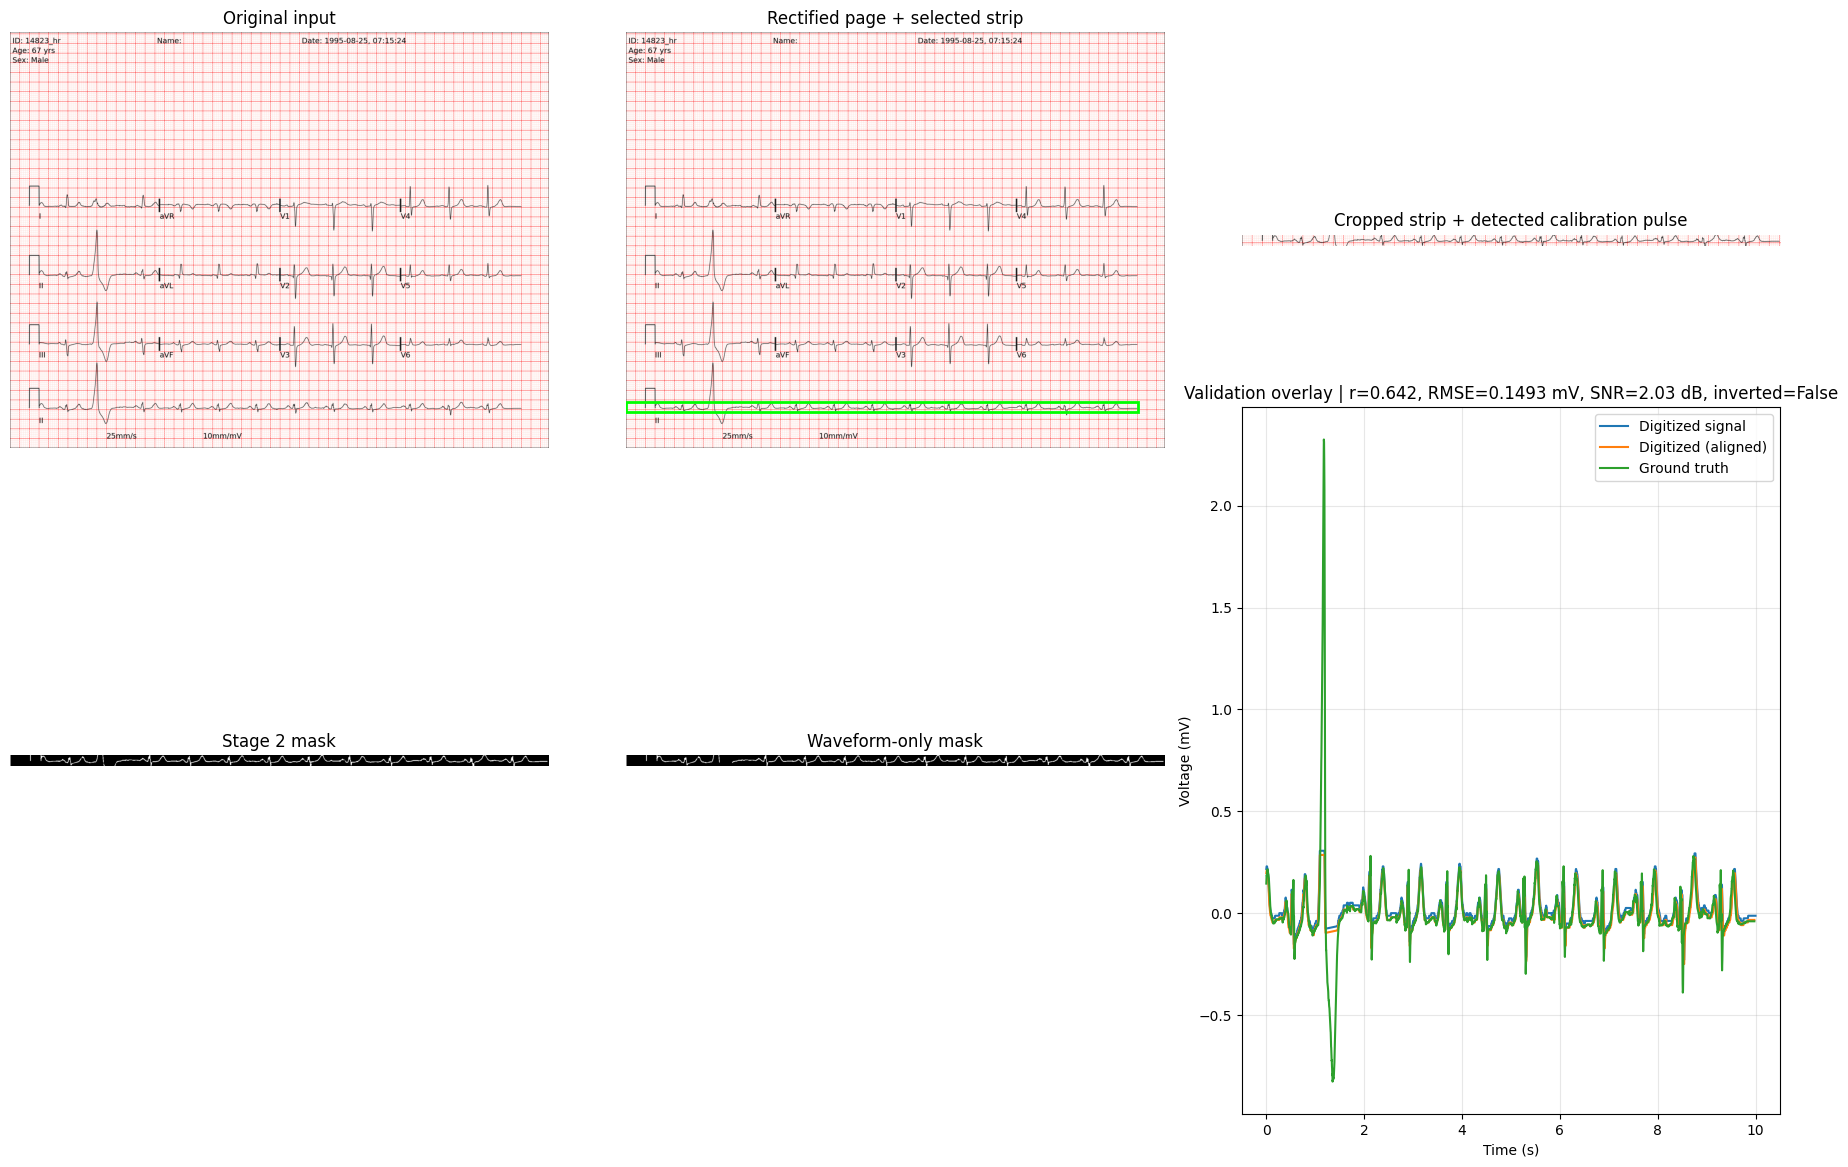

In [10]:
if sample_info["sample_id"] == "7663343" and MANUAL_STRIP_BBOX is None:
    # Best stable base Lead II strip box found during debugging for sample 7663343.
    MANUAL_STRIP_BBOX = (0, 1512, 2092, 1554)

results = run_digitization_pipeline(
    image_path=sample_info["image_path"],
    signal_path=sample_info["signal_path"],
    sample_id=sample_info["sample_id"],
    target_lead=sample_info["target_lead"],
    target_fs=TARGET_FS,
    manual_page_quad=MANUAL_PAGE_QUAD,
    manual_strip_bbox=MANUAL_STRIP_BBOX,
    output_dir=OUTPUT_DIR,
)

print_summary(results)
plot_results(results)


In [11]:
digitized_df = pd.read_csv(results["csv_path"])
display(digitized_df.head(20))
print("Total rows:", len(digitized_df))


,time_sec,voltage_mV
0,0.000,0.216837
1,0.002,0.221837
2,0.004,0.226837
3,0.006,0.229592
4,0.008,0.229592
5,0.010,0.229592
6,0.012,0.229592
7,0.014,0.229592
8,0.016,0.227857
9,0.018,0.222857


Total rows: 5000


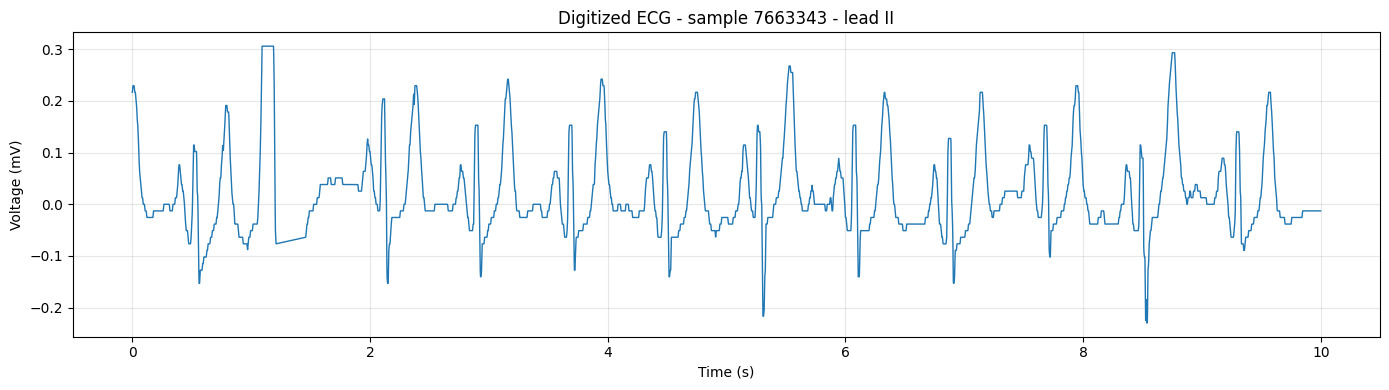

Saved summary plot: /content/ecg_digitization_project/outputs/7663343_II_summary.png


In [12]:
# Optional: export quick visual summary figure
summary_plot_path = OUTPUT_DIR / f"{sample_info['sample_id']}_{TARGET_LEAD}_summary.png"
plt.figure(figsize=(14, 4))
plt.plot(results["target_t"], results["pred_v"], linewidth=1.0)
plt.title(f"Digitized ECG - sample {sample_info['sample_id']} - lead {TARGET_LEAD}")
plt.xlabel("Time (s)")
plt.ylabel("Voltage (mV)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(summary_plot_path, dpi=180, bbox_inches="tight")
plt.show()

print("Saved summary plot:", summary_plot_path)


In [13]:
# ==========================================================
# Optional batch evaluation on multiple training samples
# ==========================================================
BATCH_SIZE = 10
batch_rows = []

for idx in range(min(BATCH_SIZE, len(train_meta))):
    try:
        info = load_sample_from_train(
            sample_index=idx,
            variant=VARIANT,
            target_lead=TARGET_LEAD,
            force=False,
        )

        out = run_digitization_pipeline(
            image_path=info["image_path"],
            signal_path=info["signal_path"],
            sample_id=info["sample_id"],
            target_lead=info["target_lead"],
            target_fs=TARGET_FS,
            manual_page_quad=None,
            manual_strip_bbox=None,
            output_dir=OUTPUT_DIR / "batch",
        )

        row = {
            "sample_index": idx,
            "sample_id": info["sample_id"],
            "status": "ok",
            "scaling_source": out["scaling_source"],
            "pearson_r": np.nan if out["metrics"] is None else out["metrics"]["pearson_r"],
            "rmse_mV": np.nan if out["metrics"] is None else out["metrics"]["rmse_mV"],
            "snr_db": np.nan if out["metrics"] is None else out["metrics"]["snr_db"],
            "signal_inverted": np.nan if out["metrics"] is None else out["metrics"]["signal_inverted"],
        }
    except Exception as e:
        row = {
            "sample_index": idx,
            "sample_id": None,
            "status": f"failed: {e}",
            "scaling_source": None,
            "pearson_r": np.nan,
            "rmse_mV": np.nan,
            "snr_db": np.nan,
            "signal_inverted": np.nan,
        }

    batch_rows.append(row)

batch_df = pd.DataFrame(batch_rows)
batch_csv_path = OUTPUT_DIR / "batch_evaluation_summary.csv"
batch_df.to_csv(batch_csv_path, index=False)

display(batch_df)
print("Saved batch summary:", batch_csv_path)


100%|██████████| 409k/409k [00:00<00:00, 22.9MB/s]

100%|██████████| 311k/311k [00:00<00:00, 8.37MB/s]

100%|██████████| 409k/409k [00:00<00:00, 16.3MB/s]

100%|██████████| 316k/316k [00:00<00:00, 27.0MB/s]

100%|██████████| 357k/357k [00:00<00:00, 11.4MB/s]

...

100%|██████████| 154k/154k [00:00<00:00, 5.60MB/s]

100%|██████████| 370k/370k [00:00<00:00, 12.7MB/s]

100%|██████████| 323k/323k [00:00<00:00, 7.34MB/s]

,sample_index,sample_id,status,scaling_source,pearson_r,rmse_mV,snr_db,signal_inverted
0,0,7663343,ok,layout_time_layout_voltage,0.661170,0.158080,1.539995,False
1,1,10140238,ok,layout_time_layout_voltage,0.136655,0.201463,-4.705152,True
2,2,11842146,ok,layout_time_layout_voltage,0.056553,0.996904,-19.484814,True
3,3,19030958,ok,layout_time_layout_voltage,0.161545,0.088579,-3.416117,False
4,4,19585145,ok,layout_time_layout_voltage,0.512416,0.130188,-1.276268,False
5,5,31175200,ok,layout_time_layout_voltage,0.281526,0.249528,-2.061399,False
6,6,31294838,ok,layout_time_layout_voltage,0.295720,0.147063,-1.535308,True
7,7,32650710,ok,layout_time_layout_voltage,0.137949,0.115413,-1.232077,True
8,8,35187032,ok,layout_time_layout_voltage,0.616921,0.257008,1.889570,False
9,9,36494663,ok,layout_time_layout_voltage,0.250275,0.225105,-3.769395,False


Saved batch summary: /content/ecg_digitization_project/outputs/batch_evaluation_summary.csv


## Notes for tuning

1. If the strip crop is slightly off, set `MANUAL_STRIP_BBOX = (x1, y1, x2, y2)` and rerun the final execution cell.
2. If you are using a photographed ECG instead of a clean Kaggle image, set `MANUAL_PAGE_QUAD` with the four paper corners if automatic rectification misses the page.
3. If the calibration pulse is not detected, the code automatically falls back to grid-based calibration using 25 mm/s and 10 mm/mV.
4. For the report, your main exported deliverables are:
   - `*_digitized.csv`
   - `*_digitized.json`
   - `*_summary.png`
   - `batch_evaluation_summary.csv` (optional)

This notebook is deterministic end-to-end and directly matches the proposal structure: geometric rectification, signal extraction, automatic reference calibration, conversion to 1D time series, and validation.
